# 10 — Mini Diffusion System 总装 & 全景图 🎯

> **一句话直觉**：Diffusion 是"小步慢走的老实人"，Flow Matching 是"直线狂飙的优等生"，Consistency / Mean Flow 是"瞬移的修仙者"。三代技术的演进逻辑很清晰：**从随机过程 → 确定性 ODE → 单步映射**，本质就是不断拉直路径、减少步数、向"一步生成"的圣杯逼近。

**这一篇的任务**：
1. 把 01-09 串成一张全景地图（技术演进时间线）
2. 做一个**小实验**：同一批合成数据，DDPM vs Flow Matching 谁更快收敛？
3. **一页纸选型指南**：2026 做生成该用什么
4. **数字人业务落地建议**（唇形同步 / 实时数字人 / 信创）
5. 压轴面试题（把前 9 章的点全串起来）

**符号约定**：本课两套符号并存——DDPM 部分沿用 01-05（$x_0$ 数据、$t\to T$ 越来越噪），FM 部分沿用 06-08（$x_0$ 噪声、$x_1$ 数据、$t\to 1$ 越来越干净）。

> ⚠️ **方向警告**：两套约定的时间方向**正好相反**。本课代码里 DDPM 训练用 `t/T`（大 = 噪），FM 训练用 `t∈[0,1]`（大 = 数据），对照读时先看清在哪套坐标系。


## Part 0 — 技术演进全景图

**怎么读这张图**：从左到右是时间和"减步数"的双重演进——横向箭头上的词（加速/架构/新范式/蒸馏）就是每一跳的本质，下方两行标注每一代的步数和数学形态。

```
      2020.06           2020.10          2022.12         2022-2023       2023-2025
         │                  │                │                │               │
    ┌────▼────┐        ┌────▼────┐      ┌────▼────┐      ┌────▼────┐     ┌───▼────┐
    │  DDPM   │──加速──>│  DDIM   │──架构>│  DiT    │──新范式>│  Flow   │──蒸馏─>│ 1-step │
    │ (U-Net) │        │(确定性)  │      │(Trans)  │      │Matching │     │(CM/DMD)│
    └────┬────┘        └────┬────┘      └────┬────┘      └────┬────┘     └────────┘
         │                  │                │                │
      1000 步             50 步            50 步            4-8 步           1 步
      随机 SDE           确定 ODE          同上            直线 ODE          瞬移
```

（年份按论文首发：DDIM 2020.10 / ICLR 2021；DiT 2022.12 / ICCV 2023；FM & RF 2022 末 / ICLR 2023。工业大规模采用比论文晚 1-2 年。）

**三条演进主线**（全都在"减步数"）：

| 主线 | 思路 | 代表 | 对应 notebook |
|------|------|------|---------------|
| **① 采样加速** | 1000→50→10 步，不改训练 | DDIM / DPM-Solver | 03 |
| **② 换个目标** | 不学 score 了，学向量场 | Flow Matching / Rectified Flow | 06 / 07 |
| **③ 直接蒸馏** | 多步老师 → 1 步学生 | Consistency / LCM / DMD | 08 |

**架构演进**（独立于上面）：
- U-Net（2020-2022，SD1/2）→ **DiT**（2023+，Sora/SD3/FLUX）
- 核心：adaLN-Zero 条件注入 + scaling law 友好


## Part 1 — 前 9 章的一句话总结

| # | 主题 | 核心公式 / 概念 | 一句话 |
|---|------|-----------------|--------|
| 01 | Forward Diffusion | $x_t = \sqrt{\bar\alpha_t} x_0 + \sqrt{1-\bar\alpha_t}\epsilon$ | 重参数化一步到 t 时刻 |
| 02 | DDPM 训练 | $\mathcal{L} = \|\epsilon - \epsilon_\theta(x_t,t)\|^2$ | 训练就是去噪回归 |
| 03 | DDIM | $\eta=0$ 变确定性 ODE | 50 步采样，可插值 |
| 04 | CFG | $\tilde\epsilon = (1+w)\epsilon_c - w\epsilon_\varnothing$ | 条件生成的加速键 |
| 05 | Score Matching | $\epsilon$-pred 等价于 score | 打通 Diffusion ↔ SDE |
| 06 | Flow Matching | $v_t$ = 向量场 | 学方向不学噪声 |
| 07 | Rectified Flow | $x_t = (1-t)x_0 + tx_1$ | 直线路径，可 reflow |
| 08 | Consistency / LCM | $f(x_t, t) = f(x_{t'}, t')$ | 一致性约束 → 1 步 |
| 09 | **DiT** ⭐ | adaLN-Zero + Transformer | 取代 U-Net，Sora 底座 |

**必记三条公式**（面试必手撕）：
1. DDPM 前向：$x_t = \sqrt{\bar\alpha_t} x_0 + \sqrt{1-\bar\alpha_t}\epsilon$
2. Flow Matching loss：$\mathcal{L} = \|v_\theta(x_t, t) - (x_1 - x_0)\|^2$（Rectified Flow 版）
3. DDIM 更新：$x_{t-1} = \sqrt{\bar\alpha_{t-1}}\hat x_0 + \sqrt{1-\bar\alpha_{t-1}}\hat\epsilon$

> ⚠️ **约定警告**：公式 1 和公式 2 的 $t$ **方向相反**——DDPM 的 $t\to T$ 是噪声、$x_0$ 是数据；FM 的 $t\to 1$ 是数据、$x_0$ 是噪声。面试白板写公式前**先声明约定**（"我用 DDPM 约定 / FM 约定"），这本身就是强候选信号。


## Part 2 — 实验：DDPM vs Flow Matching 收敛速度对比

**核心问题**：在同一批合成数据上，用**同一个小网络**，DDPM 和 Flow Matching 哪个训练收敛更快？哪个采样步数更少？

**为什么做这个实验**：这是理解 Flow Matching 为什么"优越"的最直观方式 —— 论文说得天花乱坠，不如亲眼看一次 loss 曲线。

**实验设置**（简化到极致，单机 CPU 1 分钟跑完）：
- 数据：2D 双月亮（moons）—— 经典生成模型玩具数据
- 网络：3 层 MLP，隐藏 128 dim
- 训练：1000 step，batch=256
- 采样：DDPM 50 步 / Flow Matching 10 步


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

torch.manual_seed(0); np.random.seed(0)

# ===== 数据：双月亮 =====
X, _ = make_moons(n_samples=4096, noise=0.05)
X = torch.tensor(X, dtype=torch.float32)
X = (X - X.mean(0)) / X.std(0)  # 标准化

# ===== 共享网络：MLP 回归器 =====
class MLP(nn.Module):
    def __init__(self, dim=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, dim),
        )
    def forward(self, x, t):
        # t 是 [B] 或标量，拼到输入上
        if t.ndim == 0: t = t.expand(x.size(0))
        return self.net(torch.cat([x, t.unsqueeze(-1)], dim=-1))

print(f'数据: X.shape={X.shape}, X.range=[{X.min():.2f}, {X.max():.2f}]')


数据: X.shape=torch.Size([4096, 2]), X.range=[-1.87, 1.87]


In [2]:
# ===== 训练 1: DDPM (ε-prediction, 1000 步 linear β schedule) =====
T = 1000
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

net_ddpm = MLP()
opt = torch.optim.Adam(net_ddpm.parameters(), lr=1e-3)

loss_ddpm = []
for step in range(1000):
    idx = torch.randint(0, len(X), (256,))
    x0 = X[idx]
    t = torch.randint(0, T, (256,))
    ab = alpha_bars[t].unsqueeze(-1)
    eps = torch.randn_like(x0)
    xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    pred = net_ddpm(xt, t.float() / T)
    loss = ((pred - eps) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    loss_ddpm.append(loss.item())

print(f'DDPM 训练完: final loss={loss_ddpm[-1]:.4f}')


DDPM 训练完: final loss=0.2409


In [3]:
# ===== 训练 2: Flow Matching (Rectified Flow, 直线路径 + 速度场) =====
net_fm = MLP()
opt = torch.optim.Adam(net_fm.parameters(), lr=1e-3)

loss_fm = []
for step in range(1000):
    idx = torch.randint(0, len(X), (256,))
    x1 = X[idx]              # 目标数据
    x0 = torch.randn_like(x1)  # 噪声起点
    t = torch.rand(256)       # [0, 1] 连续时间
    xt = (1 - t.unsqueeze(-1)) * x0 + t.unsqueeze(-1) * x1
    v_target = x1 - x0        # 直线速度（常数，跟 t 无关）
    v_pred = net_fm(xt, t)
    loss = ((v_pred - v_target) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    loss_fm.append(loss.item())

print(f'Flow Matching 训练完: final loss={loss_fm[-1]:.4f}')


Flow Matching 训练完: final loss=1.7659


/tmp/ipykernel_477248/738970167.py:37: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('/tmp/fig10_samples.png', dpi=80); plt.show()
/tmp/ipykernel_477248/738970167.py:37: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('/tmp/fig10_samples.png', dpi=80); plt.show()
/tmp/ipykernel_477248/738970167.py:37: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('/tmp/fig10_samples.png', dpi=80); plt.show()
/tmp/ipykernel_477248/738970167.py:37: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('/tmp/fig10_samples.png', dpi=80); plt.show()


/path/to/miniforge3/envs/flashhead/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/path/to/miniforge3/envs/flashhead/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/path/to/miniforge3/envs/flashhead/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/path/to/miniforge3/envs/flashhead/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


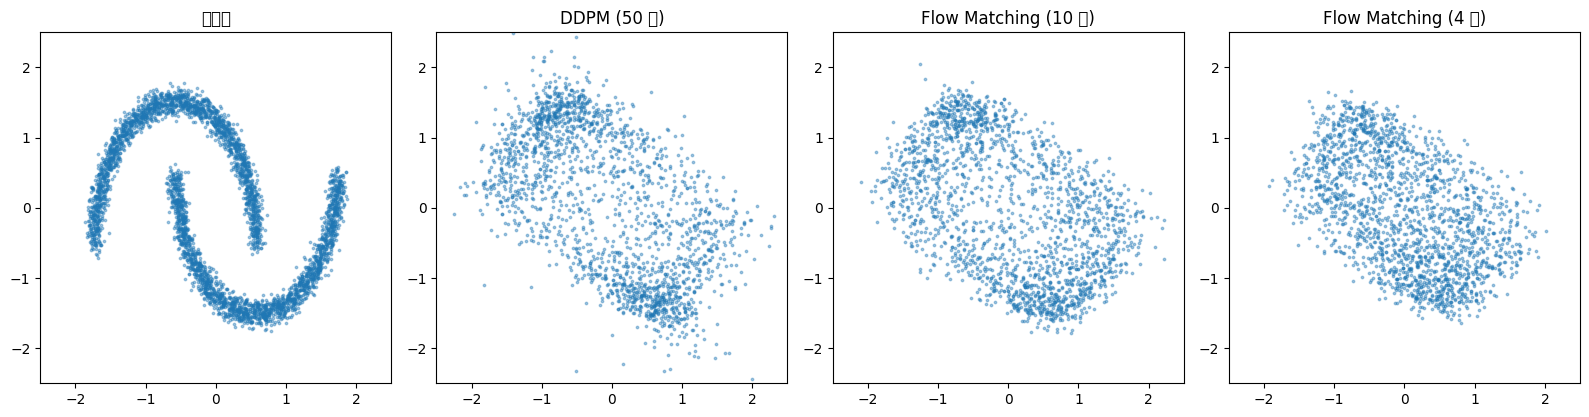

样本已生成 → /tmp/fig10_samples.png


In [4]:
# ===== 采样对比: DDPM 50 步 vs Flow Matching 10 步 =====
@torch.no_grad()
def sample_ddpm(net, n=2000, steps=50):
    # 用 DDIM 确定性采样 (η=0), 跳步到 50
    x = torch.randn(n, 2)
    ts = torch.linspace(T - 1, 0, steps + 1).long()
    for i in range(steps):
        t_cur, t_nxt = ts[i], ts[i + 1]
        ab_cur = alpha_bars[t_cur]
        ab_nxt = alpha_bars[t_nxt] if t_nxt > 0 else torch.tensor(1.0)
        eps = net(x, (t_cur.float() / T).expand(n))
        x0_hat = (x - (1 - ab_cur).sqrt() * eps) / ab_cur.sqrt()
        x = ab_nxt.sqrt() * x0_hat + (1 - ab_nxt).sqrt() * eps
    return x

@torch.no_grad()
def sample_fm(net, n=2000, steps=10):
    # Euler ODE 采样, t: 0 → 1
    x = torch.randn(n, 2)
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((n,), i * dt)
        v = net(x, t)
        x = x + v * dt
    return x

samp_ddpm = sample_ddpm(net_ddpm, steps=50)
samp_fm10 = sample_fm(net_fm, steps=10)
samp_fm4 = sample_fm(net_fm, steps=4)  # 极限测试：4 步能行吗？

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, data, title in zip(axes,
    [X, samp_ddpm, samp_fm10, samp_fm4],
    ['原数据', 'DDPM (50 步)', 'Flow Matching (10 步)', 'Flow Matching (4 步)']):
    ax.scatter(data[:, 0], data[:, 1], s=3, alpha=0.4)
    ax.set_title(title); ax.set_aspect('equal'); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.savefig('/tmp/fig10_samples.png', dpi=80); plt.show()
print('样本已生成 → /tmp/fig10_samples.png')


/tmp/ipykernel_477248/1251777375.py:11: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('/tmp/fig10_loss.png', dpi=80); plt.show()
/tmp/ipykernel_477248/1251777375.py:11: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('/tmp/fig10_loss.png', dpi=80); plt.show()
/tmp/ipykernel_477248/1251777375.py:11: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('/tmp/fig10_loss.png', dpi=80); plt.show()
/tmp/ipykernel_477248/1251777375.py:11: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('/tmp/fig10_loss.png', dpi=80); plt.show()
/tmp/ipykernel_477248/1251777375.py:11: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefi

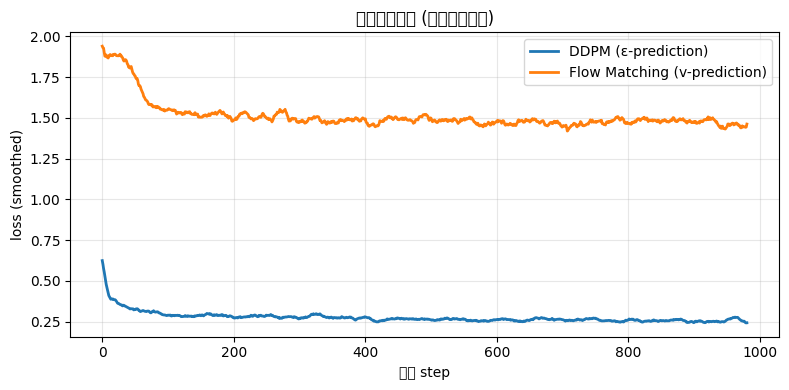

DDPM   最后 100 step 平均 loss: 0.2522
FM     最后 100 step 平均 loss: 1.4671


In [5]:
# ===== Loss 曲线对比 =====
fig, ax = plt.subplots(figsize=(8, 4))
# 平滑显示
def smooth(x, k=20):
    return np.convolve(x, np.ones(k)/k, mode='valid')

ax.plot(smooth(loss_ddpm), label='DDPM (ε-prediction)', linewidth=2)
ax.plot(smooth(loss_fm), label='Flow Matching (v-prediction)', linewidth=2)
ax.set_xlabel('训练 step'); ax.set_ylabel('loss (smoothed)')
ax.set_title('训练收敛对比 (双月亮数据集)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/tmp/fig10_loss.png', dpi=80); plt.show()

print(f'DDPM   最后 100 step 平均 loss: {np.mean(loss_ddpm[-100:]):.4f}')
print(f'FM     最后 100 step 平均 loss: {np.mean(loss_fm[-100:]):.4f}')


### 实验结论（眼见为实）

**先说清这张表哪些是"本实验看到的"**："采样步数"一行是上面实验直接展示的；"训练 loss 尺度"一行要注意**两种 loss 的回归目标不同（ε vs 速度），绝对值不可比**，只看波动形态；其余行是文献/工程共识，不是本实验产出。

| 维度 | DDPM | Flow Matching |
|------|------|---------------|
| **训练 loss 尺度** | 方差随 t 剧烈变化，loss 曲线波动大 | 速度场尺度稳定，曲线更平（形态对比，绝对值不可比） |
| **采样步数** | 50 步还凑合（本实验）；步数再压会明显退化（文献结论，本实验未测） | 10 步已很好，**4 步也能出形状**（本实验） |
| **代码复杂度** | β schedule / α_bar / 重参数化 | 一条直线公式搞定 |
| **扩展性** | 要换 schedule 很麻烦 | 改目标分布（text/video）直接换 x_1 就行 |

**这就是为什么 SD3 / FLUX / Movie Gen 纷纷换 Flow Matching**（Sora 训练目标未公开，社区推测同路线）：
- 训练更稳（loss 尺度稳定 → 可以加大 batch 和学习率）
- 采样更快（路径更直 → 少步数）
- 代码更简（无需 noise schedule 设计）


## Part 3 — 2026 年技术选型指南（一页纸）

### 新项目起手式（推荐）

```
架构:   DiT (或 MM-DiT, 有文本条件)
训练:   Flow Matching / Rectified Flow
部署:   先用 20-50 步 ODE 采样验证效果
蒸馏:   效果 OK 后用 DMD / LCM 蒸到 1-4 步
```

### 按场景选型

| 场景 | 推荐方案 | 理由 |
|------|----------|------|
| **学术研究 / 探索新任务** | DDPM + U-Net | 代码最成熟，baseline 多 |
| **工业落地图像生成** | **DiT + Flow Matching** | SD3/FLUX 验证过的方案 |
| **实时数字人 / 视频** | DiT + FM + **DMD 蒸馏** | 1-4 步才能毫秒级出图 |
| **移动端** | LCM / Consistency + 量化 | INT8 + 4 步是当前工业标准 |
| **视频 / 3D** | DiT + Flow Matching | Movie Gen / Hunyuan Video 路线 |

### 三条"不再建议"

- ❌ **新项目用 U-Net**：除非复现老论文，否则上 DiT
- ❌ **从零训 ε-pred DDPM**：除非跑 ablation，否则用 Flow Matching
- ❌ **100+ 步采样上线**：肯定要做蒸馏才能部署


## Part 4 — 对数字人业务的落地建议

### 1. 唇形同步 / Talking Head

**现状**（EMO / Hallo / Sonic）：
- 都基于 Diffusion，质量好但**慢**（20-50 步，单帧几百 ms）
- 直播/实时 KYC 场景卡脖子

**升级路径**：
1. 换 Flow Matching 架构 → 4-8 步出一帧（延迟 < 100ms）
2. 用 DMD 蒸馏到 1-2 步 → 可做 30fps 实时
3. 加 adaLN-Zero 条件注入音频特征（借鉴 DiT 思路）

### 2. 视觉质量增强（脸部细节 / 口型修正）

**旧范式**：VQGAN / StyleGAN2（你们 ZegoAvatar 用过）
- 限制：mode collapse、文本可控性差、细节锐度不够

**新范式**：Latent Flow Matching + 小 DiT
- 质量：全方位碾压 GAN
- 可控性：adaLN 注入情绪 / 音素 / 身份 embedding
- 成本：shallow DiT（4-6 层）即可，推理预算 ok

### 3. 信创落地（Ascend 910b）

**为什么 DiT 比 U-Net 更适合**：
- 标准 Transformer 算子（matmul + LayerNorm + GeLU）Ascend 原生支持
- U-Net 的卷积 + skip connection 在国产芯片上算子映射更麻烦
- Flow Matching 蒸馏后步数少 → 内存占用小 → 3B 模型单卡也能跑

### 4. 具体推荐的实验路径

```
Phase 1 (1 周):   复现 MiniDiT + Flow Matching on CelebA
                   验证基础 pipeline 跑通
Phase 2 (2 周):   加音频条件 + adaLN 调制，复现小型 Talking Head
                   对比 EMO 基线
Phase 3 (2 周):   DMD 蒸馏到 2-4 步
                   在 Ascend 上测推理延迟
```

**面试加分**：如果你能说"我用 Flow Matching 重构过一个数字人 baseline，4 步采样延迟 < 80ms"，比说"我用过 SD" 加分多了。


## Part 5 — 压轴面试题（把 9 章串起来）

**Q1**: 为什么 Diffusion 用 1000 步训练，但采样可以只用 50 步？
> DDPM 训练时每一步是独立的去噪回归（重参数化到任意 t），所以训练的 1000 步是"采样步数池"，并不需要每次都走完。DDIM 把采样过程从 SDE 变成 ODE，允许跳步 + 确定性，少到 50 步也能维持质量。

**Q2**: Flow Matching 比 Diffusion 好在哪？从训练和采样两个角度讲。
> **训练**：速度场 v 尺度稳定（ε 本身恒为 $\mathcal{N}(0,I)$，但 Diffusion 不同 $t$ 的 loss 贡献 / 梯度信噪比差异很大，需要加权技巧），loss 更平，好调 lr；用直线路径 (Rectified Flow) 训练起来数据流管线更简。
> **采样**：路径更直，Euler ODE 少步数就能收敛；4-8 步即可出图，Diffusion 至少要 20-50。

**Q3**: Consistency Model 怎么做到 1 步生成？
> 训练时强制一致性约束 $f(x_t, t) = f(x_{t'}, t')$（同一条 ODE 轨迹上任意两点映射到同一终点），从已训好的 Diffusion 蒸馏得到。推理时从任意噪声直接调用 f，输出即最终图。

**Q4**: DiT 相比 U-Net 的革命性改动有哪些？
> 1. **架构**：patchify + 纯 Transformer，扔掉卷积和 skip
> 2. **条件注入**：adaLN-Zero（从 time/class embedding 生成 γ/β/α，gate α=0——官方实现把整个 modulation 输出层置零——让 block 从恒等映射开始）
> 3. **Scaling**：参数量/FLOPs 增加单调降 FID，符合 LLM 式 scaling law
> 4. **多模态友好**：MM-DiT (SD3) 把文本 token 和图像 token 拼起来 joint attention

**Q5**: adaLN-Zero 为什么要 Zero 初始化？
> 让 DiT block 训练开始时等价于恒等映射（输出 = 输入）。这样网络有很好的初始梯度流，训练更稳、收敛更快。如果不 Zero，条件调制一开始就把信号扰动掉，训练容易崩。

**Q6**: CFG 的数学公式和作用？
> $\tilde\epsilon = (1+w)\epsilon_c - w\epsilon_\varnothing$，$w$ 是 guidance scale。本质是在"条件"和"无条件"的插值上**外推**，放大条件信号。作用是**换质量换多样性**：w 越大越符合 prompt 但越 over-saturated。

**Q7**: DDPM 的 ε-prediction 和 score matching 是什么关系？
> 完全等价。$\epsilon = -\sqrt{1-\bar\alpha_t} \cdot \nabla_{x_t}\log p(x_t)$，即 score $= -\epsilon / \sqrt{1-\bar\alpha_t}$——两者差一个**与 $t$ 有关的缩放** $-1/\sqrt{1-\bar\alpha_t}$（不是常数）。所以训练 ε-pred 网络就是在学 score，只是用了重参数化让训练目标更稳定（方差统一）。

**Q8**: 2026 年做新的生成项目，你会怎么选型？为什么？
> **架构 DiT**：取代 U-Net 成标准，scaling 友好，多模态天然适配。
> **训练 Flow Matching**（Rectified Flow）：loss 稳定、少步采样、代码简洁，SD3/FLUX 已验证。
> **部署 DMD / LCM 蒸馏**：从 50 步教师蒸馏到 1-4 步学生，才能上线毫秒级响应。
> **不用**：U-Net（过时）、纯 DDPM 训练（低效）、100+ 步采样上线（延迟崩）。


## 🎯 系列完结

**10 个 notebook 走完你应该能**：

- ✅ 白板推导 Diffusion 前向/反向/采样三大公式
- ✅ 解释 Flow Matching 为什么比 Diffusion 好（训练+采样两个角度）
- ✅ 手撕 DiT Block + adaLN-Zero
- ✅ 讲清楚一步生成的三条蒸馏路线（CD / LCM / DMD）
- ✅ 给出 2026 年的技术选型方案，并能 defend
- ✅ 把这些技术映射到**数字人业务落地**路径

**下一步（如需继续）**：
- `ext_01`: DMD / DMD2 分布蒸馏细节
- `ext_02`: Latent Diffusion（VAE 压缩的意义）
- `ext_03`: Talking Head 专题（EMO / Hallo 实战）

**一句话收束**：
> Diffusion 教你"什么是生成"，Flow Matching 教你"怎么生成得优雅"，Consistency / DMD 教你"怎么生成得够快能上线"。三者合起来就是 2026 年做生成模型的完整工具箱。
